#1.1

In [ ]:
from ucimlrepo import fetch_ucirepo
default_of_credit_card_clients = fetch_ucirepo(id=350)

X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets
df = pd.concat([X, y], axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

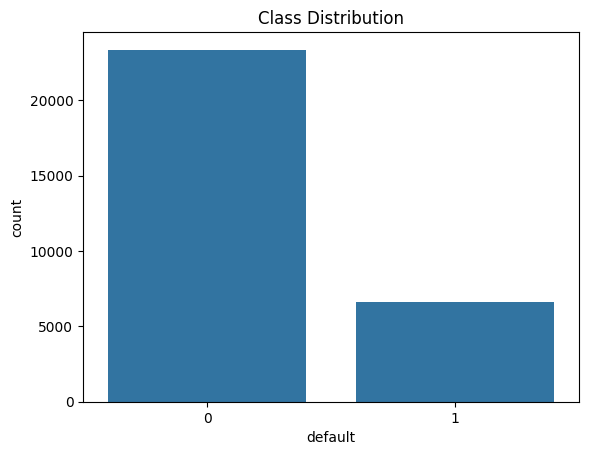

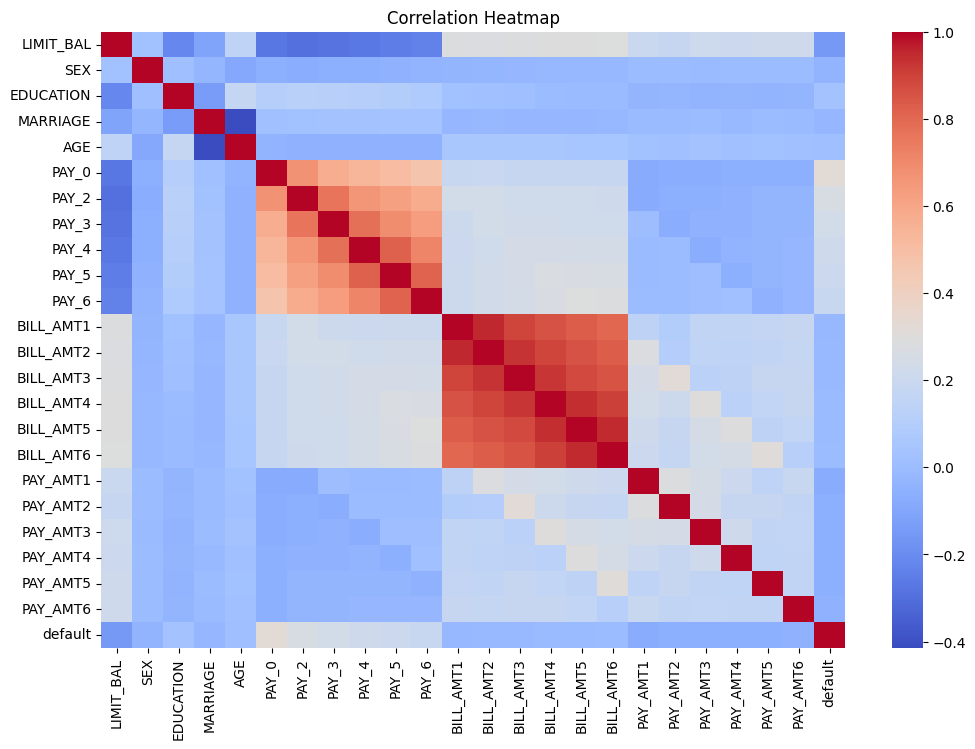

In [ ]:
df = pd.concat([X, y], axis=1)

# Rename columns for clarity
df.rename(columns={
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6',
    'Y': 'default'
}, inplace=True)

# Basic info
print(df.info())
print(df.describe())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Class distribution
sns.countplot(x='default', data=df)
plt.title("Class Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#1.2

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fix invalid categories
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Features & target
X = df.drop(columns=['default'])
y = df['default']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#1.3

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Linear SVM (fast)
svm_linear = LinearSVC(max_iter=2000)
svm_linear.fit(X_train_scaled, y_train)

# RBF SVM (no grid search to avoid slow training)
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)

# Decision Tree
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)

# Evaluation
models = {
    "Logistic": log_reg,
    "SVM Linear": svm_linear,
    "SVM RBF": svm_rbf,
    "Decision Tree": tree
}

for name, model in models.items():
    if name == "Decision Tree":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000


SVM Linear
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      4673
           1       0.73      0.18      0.29      1327

    accuracy                           0.80      6000
   macro avg       0.77      0.58      0.59      6000
weighted avg       0.79      0.80      0.76      6000


SVM RBF
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79

#1.4

In [ ]:
# Logistic Regression WITHOUT scaling
lr_no_scale = LogisticRegression(
    max_iter=3000,
    solver='saga',   # better for large/unscaled data
    tol=1e-3
)

lr_no_scale.fit(X_train, y_train)

# Predictions
y_pred_no_scale = lr_no_scale.predict(X_test)
y_pred_scaled = log_reg.predict(X_test_scaled)

print("F1 without scaling:", f1_score(y_test, y_pred_no_scale))
print("F1 with scaling:", f1_score(y_test, y_pred_scaled))

# Decision Tree (no scaling effect)
y_pred_tree = tree.predict(X_test)
print("Decision Tree F1:", f1_score(y_test, y_pred_tree))

F1 without scaling: 0.0
F1 with scaling: 0.35825892857142855
Decision Tree F1: 0.45987198424421466


#1.5

In [ ]:
for split in [0.2, 0.3, 0.4]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=split, stratify=y, random_state=42
    )

    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # Train models
    svm_rbf.fit(X_tr_s, y_tr)
    tree.fit(X_tr, y_tr)

    rbf_score = f1_score(y_te, svm_rbf.predict(X_te_s))
    dt_score = f1_score(y_te, tree.predict(X_te))

    print(f"Split {split}: RBF={rbf_score:.3f}, DT={dt_score:.3f}")

Split 0.2: RBF=0.449, DT=0.462
Split 0.3: RBF=0.436, DT=0.451
Split 0.4: RBF=0.435, DT=0.456


#1.6

In [ ]:
from sklearn.feature_selection import RFE

rfe_model = LogisticRegression(max_iter=1000)

rfe = RFE(rfe_model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# Selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

# Train with reduced features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

rfe_model.fit(X_train_rfe, y_train)
y_pred_rfe = rfe_model.predict(X_test_rfe)

print("F1 after RFE:", f1_score(y_test, y_pred_rfe))

Selected Features: Index(['LIMIT_BAL', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'PAY_AMT1', 'PAY_AMT2'],
      dtype='object')
F1 after RFE: 0.3542019176536943


#2 QUESTION

In [ ]:
# Install the library if not already present
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset
bike_sharing = fetch_ucirepo(id=275)

# Get data as pandas dataframes
X = bike_sharing.data.features
y = bike_sharing.data.targets

# Combine features and targets if needed
df = pd.concat([X, y], axis=1)
print(df.head())


       dteday  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  \
0  2011-01-01       1   0     1   0        0        6           0           1   
1  2011-01-01       1   0     1   1        0        6           0           1   
2  2011-01-01       1   0     1   2        0        6           0           1   
3  2011-01-01       1   0     1   3        0        6           0           1   
4  2011-01-01       1   0     1   4        0        6           0           1   

   temp   atemp   hum  windspeed  cnt  
0  0.24  0.2879  0.81        0.0   16  
1  0.22  0.2727  0.80        0.0   40  
2  0.22  0.2727  0.80        0.0   32  
3  0.24  0.2879  0.75        0.0   13  
4  0.24  0.2879  0.75        0.0    1  


#2.1

(17379, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB
None
             season            yr          mnth            hr       holiday  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000  

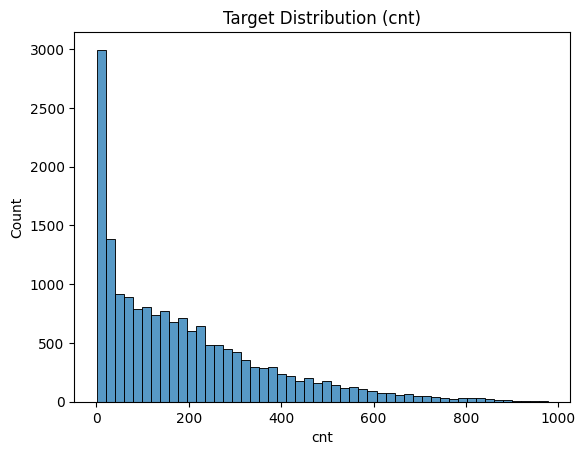

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
print(df.shape)
print(df.info())
print(df.describe())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Target distribution
plt.figure()
sns.histplot(df['cnt'], bins=50)
plt.title("Target Distribution (cnt)")
plt.show()



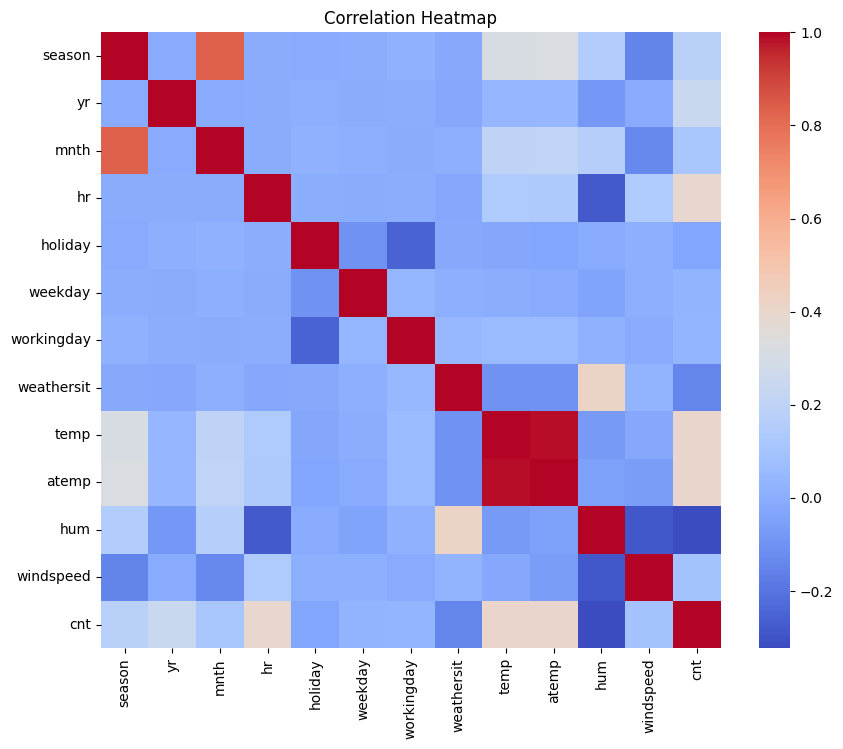

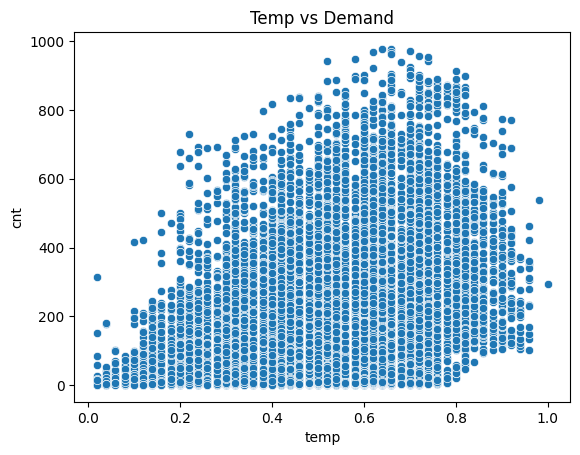

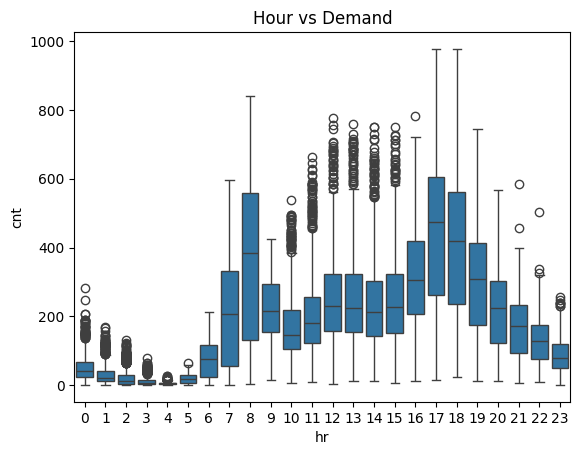

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
df_numeric = df.select_dtypes(include='number')

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Relationships
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temp vs Demand")
plt.show()

sns.boxplot(x='hr', y='cnt', data=df)
plt.title("Hour vs Demand")
plt.show()

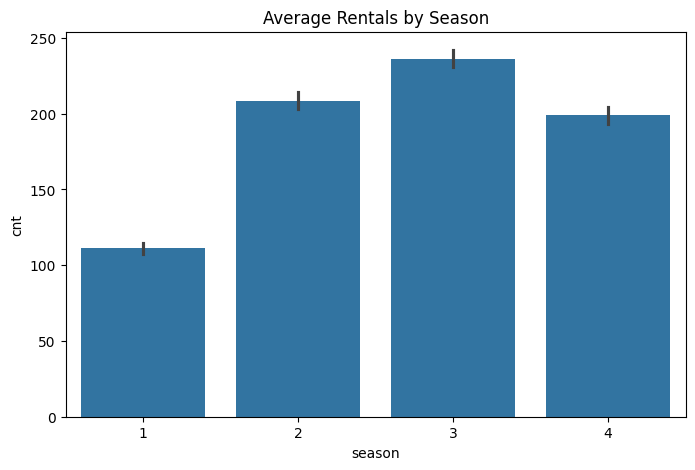

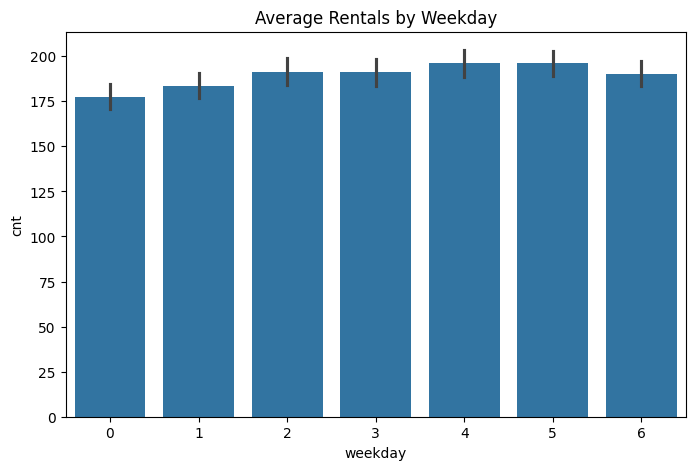

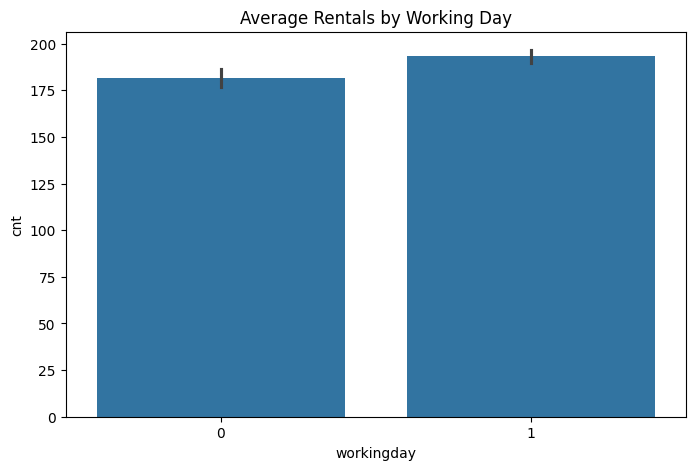

In [ ]:
# Season
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data=df)
plt.title("Average Rentals by Season")
plt.show()

# Weekday
plt.figure(figsize=(8,5))
sns.barplot(x='weekday', y='cnt', data=df)
plt.title("Average Rentals by Weekday")
plt.show()

# Working Day
plt.figure(figsize=(8,5))
sns.barplot(x='workingday', y='cnt', data=df)
plt.title("Average Rentals by Working Day")
plt.show()

#2.2

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep time version for later
df_time = df.copy()

# Drop date for modeling
df_model = df.drop('dteday', axis=1)

X = df_model.drop('cnt', axis=1)
y = df_model['cnt']

# Categorical & numerical
categorical_cols = [
    'season','yr','mnth','hr','holiday',
    'weekday','workingday','weathersit'
]

# One-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#2.3

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

# 🔹 Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("\nLinear Regression")
evaluate(lr, X_test_scaled, y_test)

# 🔹 SVR Linear
svr_linear = GridSearchCV(
    SVR(kernel='linear'),
    {'C': [0.1, 1, 10]},
    cv=3
)
svr_linear.fit(X_train_scaled, y_train)

print("\nSVR Linear")
evaluate(svr_linear, X_test_scaled, y_test)

# 🔹 SVR RBF
svr_rbf = GridSearchCV(
    SVR(kernel='rbf'),
    {'C': [1, 10], 'gamma': ['scale', 0.01]},
    cv=3
)
svr_rbf.fit(X_train_scaled, y_train)

print("\nSVR RBF")
evaluate(svr_rbf, X_test_scaled, y_test)

# 🔹 Decision Tree
tree = GridSearchCV(
    DecisionTreeRegressor(),
    {'max_depth': [5, 10, None]},
    cv=3
)
tree.fit(X_train, y_train)

print("\nDecision Tree")
evaluate(tree, X_test, y_test)


Linear Regression
RMSE: 100.44594623557185
R2: 0.681375112801918

SVR Linear
RMSE: 104.85679710245061
R2: 0.6527773543896492

SVR RBF
RMSE: 78.98921112119902
R2: 0.80296180563535

Decision Tree
RMSE: 71.1683126506917
R2: 0.8400485415543837


#2.4

In [ ]:
# Sort by time
df_time = df_time.sort_values('dteday')

X_time = df_time.drop(['cnt','dteday'], axis=1)
y_time = df_time['cnt']

# One-hot encode
X_time = pd.get_dummies(X_time, drop_first=True)

split = int(0.8 * len(df_time))

X_train_t = X_time[:split]
X_test_t = X_time[split:]

y_train_t = y_time[:split]
y_test_t = y_time[split:]

# Scale
scaler = StandardScaler()
X_train_t = scaler.fit_transform(X_train_t)
X_test_t = scaler.transform(X_test_t)

# Train best model (use RBF SVR)
model = SVR(kernel='rbf', C=10, gamma='scale')
model.fit(X_train_t, y_train_t)

print("\nTemporal Split Performance")
evaluate(model, X_test_t, y_test_t)


Temporal Split Performance
RMSE: 189.86555072448257
R2: 0.2569635638048622


#2.5

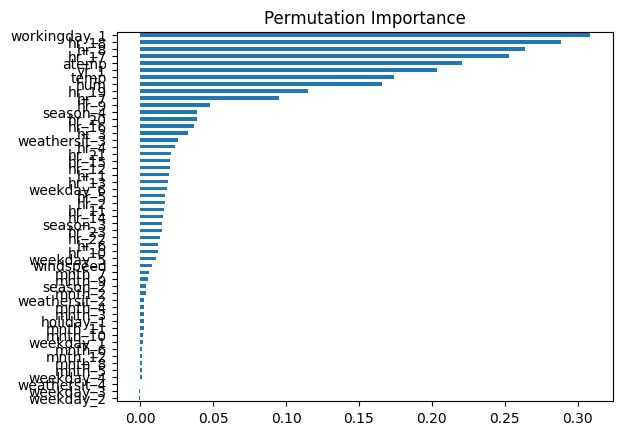

In [ ]:
from sklearn.inspection import permutation_importance

model = tree.best_estimator_

result = permutation_importance(model, X_test, y_test, n_repeats=5)

importance = pd.Series(result.importances_mean, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

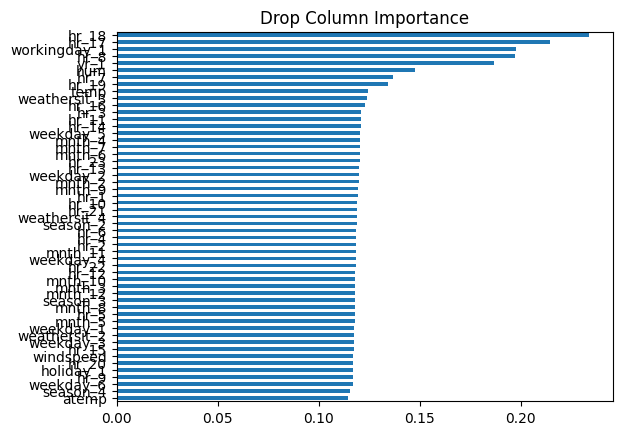

In [ ]:
baseline = tree.best_estimator_.score(X_test, y_test)

drop_importance = {}

for col in X.columns:
    X_train_drop = X_train.drop(col, axis=1)
    X_test_drop = X_test.drop(col, axis=1)

    model = DecisionTreeRegressor(max_depth=10)
    model.fit(X_train_drop, y_train)

    score = model.score(X_test_drop, y_test)
    drop_importance[col] = baseline - score

pd.Series(drop_importance).sort_values().plot(kind='barh')
plt.title("Drop Column Importance")
plt.show()

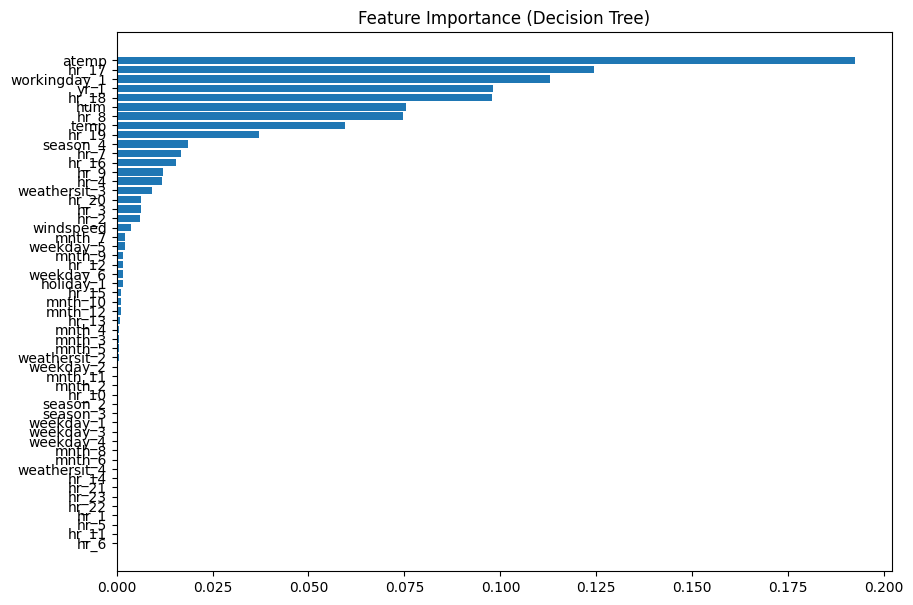


Top 5 Features:
         Feature  Importance
1          atemp    0.192321
35         hr_17    0.124301
49  workingday_1    0.113009
7           yr_1    0.097982
36         hr_18    0.097938


In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=10)
model.fit(X_train, y_train)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10,7))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Feature Importance (Decision Tree)")
plt.show()

# Top 5
print("\nTop 5 Features:")
print(feat_imp.sort_values('Importance', ascending=False).head(5))

#3RD QUESTION

In [ ]:
red_df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
    sep=";"
)

white_df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv",
    sep=";"
)

red_df['color'] = 'red'
white_df['color'] = 'white'

df = pd.concat([red_df, white_df], axis=0)

print(df.shape)
df.head(10)


(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red


#3.1

Red wine shape: (1599, 13)
White wine shape: (4898, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB
None
       

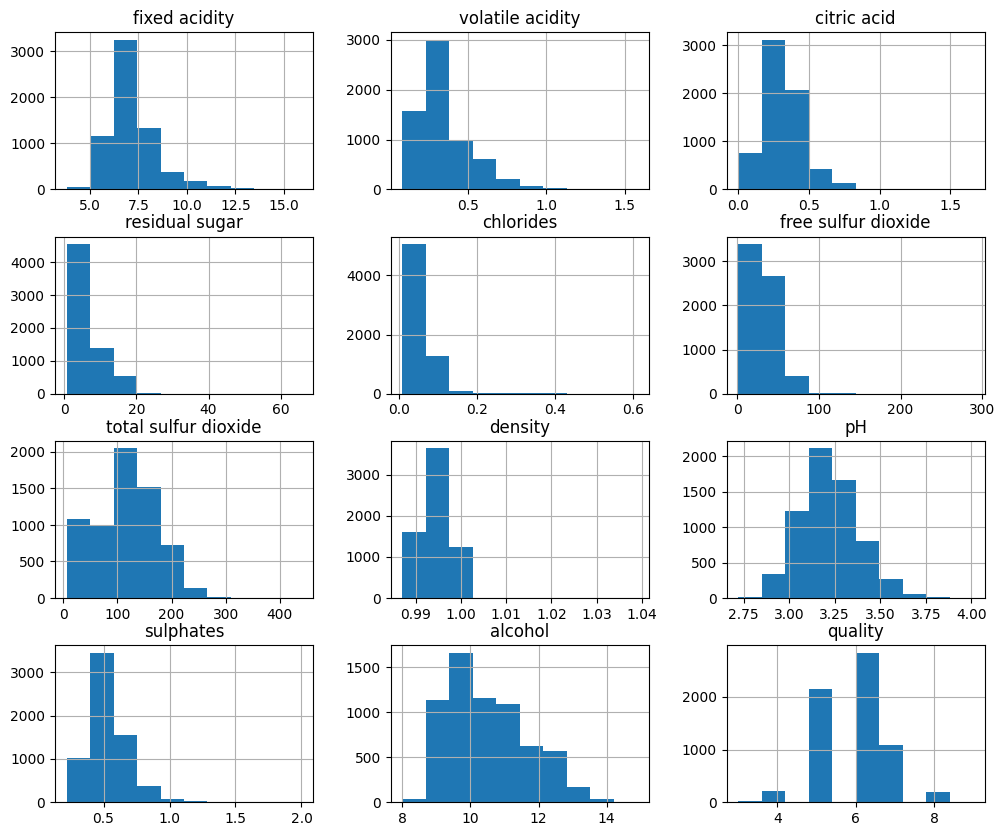

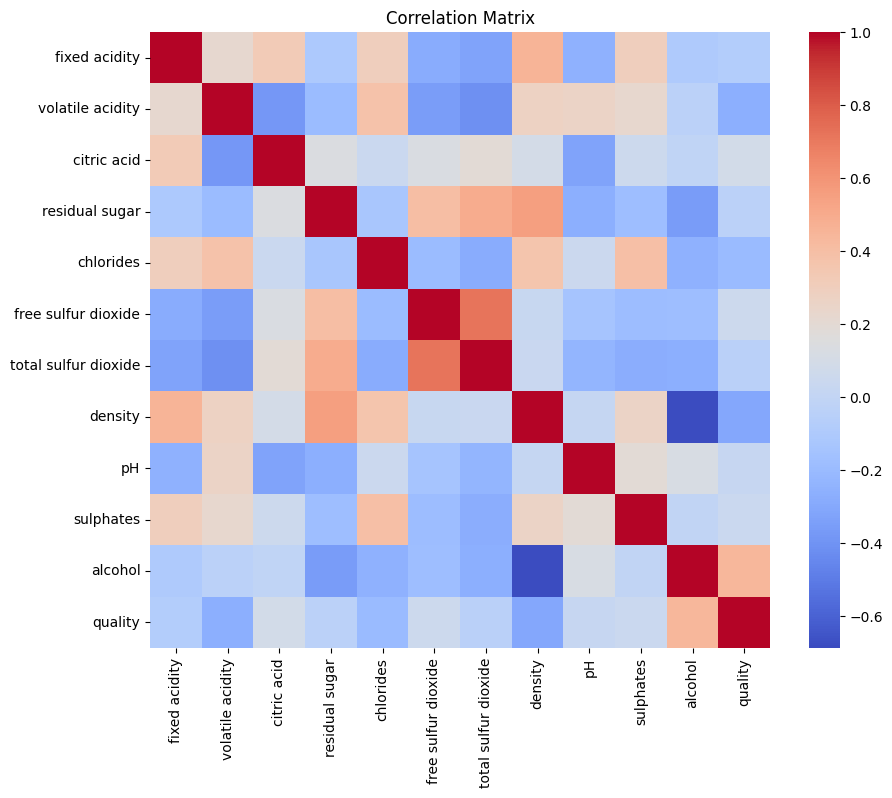

In [ ]:
print("Red wine shape:", red_df.shape)
print("White wine shape:", white_df.shape)
red_df = df[df['color'] == 'red']
white_df = df[df['color'] == 'white']
# Basic info
print(df.info())
print(df.describe())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Label distribution
print("\nQuality distribution:\n", df['quality'].value_counts().sort_index())

# Histogram
df.hist(figsize=(12,10))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#3.2

In [ ]:
# Split features/target
X = df.drop(['quality', 'color'], axis=1)
y = df['quality']

# Log transform skewed feature
X['residual sugar'] = np.log1p(X['residual sugar'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (6497, 11)
Reduced shape: (6497, 8)


#3.3

In [ ]:
red_df = df[df['color'] == 'red']
white_df = df[df['color'] == 'white']

def prepare_data(data):
    X = data.drop(['quality', 'color'], axis=1)
    y = data['quality']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Xr_train, Xr_test, yr_train, yr_test = prepare_data(red_df)
Xw_train, Xw_test, yw_train, yw_test = prepare_data(white_df)

In [ ]:
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, f1_score

def run_regression(X_train, X_test, y_train, y_test):
    model = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    print("RMSE:", rmse)
    print("MAE:", mae)

print("RED WINE - REGRESSION")
run_regression(Xr_train, Xr_test, yr_train, yr_test)

print("\nWHITE WINE - REGRESSION")
run_regression(Xw_train, Xw_test, yw_train, yw_test)

RED WINE - REGRESSION


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RMSE: 0.6308724466517464
MAE: 0.5002072848496448

WHITE WINE - REGRESSION
RMSE: 0.7057465533226831
MAE: 0.5480627252080977


In [ ]:
def run_classification(X_train, X_test, y_train, y_test):
    model = MLPClassifier(hidden_layer_sizes=(32,), max_iter=500)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("F1-score (macro):", f1_score(y_test, pred, average='macro'))
    print(classification_report(y_test, pred))

print("RED WINE - CLASSIFICATION")
run_classification(Xr_train, Xr_test, yr_train, yr_test)

print("\nWHITE WINE - CLASSIFICATION")
run_classification(Xw_train, Xw_test, yw_train, yw_test)

RED WINE - CLASSIFICATION


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and bei

F1-score (macro): 0.2835405721972886
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.66      0.74      0.70       130
           6       0.56      0.58      0.57       132
           7       0.47      0.40      0.44        42
           8       0.00      0.00      0.00         5

    accuracy                           0.59       320
   macro avg       0.28      0.29      0.28       320
weighted avg       0.56      0.59      0.57       320


WHITE WINE - CLASSIFICATION
F1-score (macro): 0.3721957722047227
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.30      0.12      0.17        25
           5       0.60      0.58      0.59       291
           6       0.57      0.71      0.63       432
           7       0.56      0.39      0.46       192
           8       0.29      

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
def ordinal_transform(y, n_classes):
    return np.array([[1 if yi >= k else 0 for k in range(n_classes)] for yi in y])

def run_ordinal(X_train, X_test, y_train, y_test):
    n_classes = int(y_train.max()) + 1

    y_train_ord = ordinal_transform(y_train, n_classes)

    model = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
    model.fit(X_train, y_train_ord)

    pred = model.predict(X_test)

    # Convert back
    pred_labels = np.sum(pred > 0.5, axis=1)

    mae = mean_absolute_error(y_test, pred_labels)
    print("Ordinal MAE:", mae)

print("RED WINE - ORDINAL")
run_ordinal(Xr_train, Xr_test, yr_train, yr_test)

print("\nWHITE WINE - ORDINAL")
run_ordinal(Xw_train, Xw_test, yw_train, yw_test)

RED WINE - ORDINAL
Ordinal MAE: 0.91875

WHITE WINE - ORDINAL
Ordinal MAE: 1.0081632653061225


#3.4

In [ ]:
model = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
model.fit(Xr_train, yr_train)

pred_cross = model.predict(Xw_test)

print("Cross-domain RMSE:", np.sqrt(mean_squared_error(yw_test, pred_cross)))

Cross-domain RMSE: 0.9390680878704986


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
model = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
model.fit(Xw_train, yw_train)

pred_cross = model.predict(Xr_test)

print("Cross-domain RMSE:", np.sqrt(mean_squared_error(yr_test, pred_cross)))

Cross-domain RMSE: 0.8907467309350955


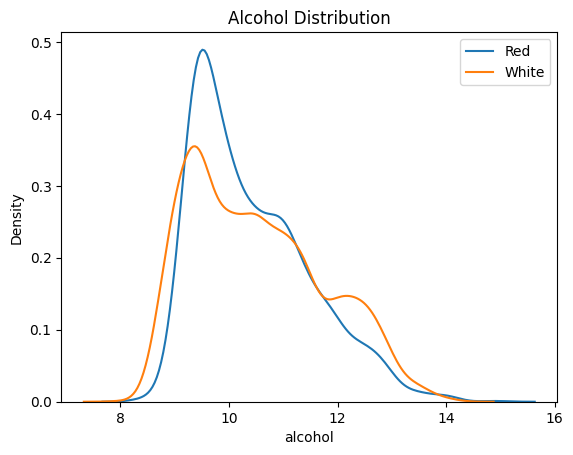

In [ ]:
sns.kdeplot(red_df['alcohol'], label='Red')
sns.kdeplot(white_df['alcohol'], label='White')
plt.legend()
plt.title("Alcohol Distribution")
plt.show()